In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('All imports OK')

All imports OK


In [2]:

# SECTION 1: DATA LOADING & UNDERSTANDING

import pandas as pd
import numpy as np

# Load the datasets
print("Loading data...")
train = pd.read_csv("d:/datasets/train.csv")
test = pd.read_csv("d:/datasets/test.csv")

# Check the shape (rows x columns)
print(f"\nTrain data: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test data:  {test.shape[0]} rows, {test.shape[1]} columns")

# Look at first few rows
print("\n--- First 5 rows of training data ---")
print(train.head())

# Check column names
print("\n--- Column names ---")
print(train.columns.tolist())

# Check data types
print("\n--- Data types ---")
print(train.dtypes)

# Basic statistics
print("\n--- Basic statistics ---")
print(train.describe())

# Check target variable (what we're predicting)
print("\n--- Target variable distribution ---")
print(train['Churn'].value_counts())
print(f"\nChurn rate: {(train['Churn'] == 'Yes').sum() / len(train) * 100:.2f}%")

Loading data...

Train data: 594194 rows, 21 columns
Test data:  254655 rows, 20 columns

--- First 5 rows of training data ---
   id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0   0    Male              0     Yes        Yes      29          Yes   
1   1    Male              0     Yes        Yes      58          Yes   
2   2    Male              0     Yes         No      58          Yes   
3   3  Female              0      No         No       1          Yes   
4   4  Female              0      No         No       1          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL            Yes  ...              Yes   
1            No             DSL            Yes  ...               No   
2           Yes     Fiber optic             No  ...               No   
3            No     Fiber optic             No  ...               No   
4            No     Fiber optic             No  ...               No   

  Tech

In [3]:
# ============================================================
# SECTION 2: DATA CLEANING
# ============================================================

print("=" * 60)
print("SECTION 2: DATA CLEANING")
print("=" * 60)

# Step 1: Check for missing values
print("\n--- Checking for missing values ---")
print("\nTraining data missing values:")
missing_train = train.isnull().sum()
print(missing_train[missing_train > 0])  # Only show columns with missing data

print("\nTest data missing values:")
missing_test = test.isnull().sum()
print(missing_test[missing_test > 0])

# Step 2: Fix TotalCharges column (it has spaces that cause problems)
print("\n--- Fixing TotalCharges column ---")

# Convert TotalCharges to numeric (spaces will become NaN)
train['TotalCharges'] = pd.to_numeric(train['TotalCharges'], errors='coerce')
test['TotalCharges'] = pd.to_numeric(test['TotalCharges'], errors='coerce')

# Check how many NaN we created
print(f"NaN values in train TotalCharges: {train['TotalCharges'].isnull().sum()}")
print(f"NaN values in test TotalCharges: {test['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with median (middle value)
median_charges = train['TotalCharges'].median()
print(f"\nFilling missing values with median: {median_charges:.2f}")

train['TotalCharges'].fillna(median_charges, inplace=True)
test['TotalCharges'].fillna(median_charges, inplace=True)

# Step 3: Verify - no missing values left
print("\n--- After cleaning ---")
print(f"Missing values in train: {train.isnull().sum().sum()}")
print(f"Missing values in test: {test.isnull().sum().sum()}")

# Step 4: Save IDs and target separately
print("\n--- Separating IDs and target variable ---")
train_ids = train['id']
test_ids = test['id']

# Convert target from Yes/No to 1/0
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0})
y = train['Churn']  # This is what we're predicting

print(f"Target variable (y) shape: {y.shape}")
print(f"Positive class (Churn=1): {y.sum()} customers ({y.mean()*100:.2f}%)")

print("\n✅ Data cleaning complete!")

SECTION 2: DATA CLEANING

--- Checking for missing values ---

Training data missing values:
Series([], dtype: int64)

Test data missing values:
Series([], dtype: int64)

--- Fixing TotalCharges column ---
NaN values in train TotalCharges: 0
NaN values in test TotalCharges: 0

Filling missing values with median: 1433.65

--- After cleaning ---
Missing values in train: 0
Missing values in test: 0

--- Separating IDs and target variable ---
Target variable (y) shape: (594194,)
Positive class (Churn=1): 133817 customers (22.52%)

✅ Data cleaning complete!


In [5]:
train.head(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0


SECTION 3: EXPLORATORY DATA ANALYSIS

--- 3.1: Target Variable Distribution ---


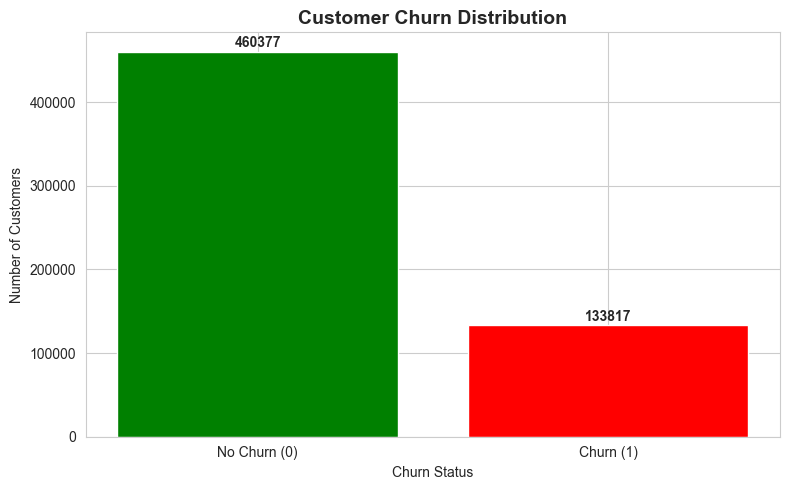


--- 3.2: Numerical Features Analysis ---


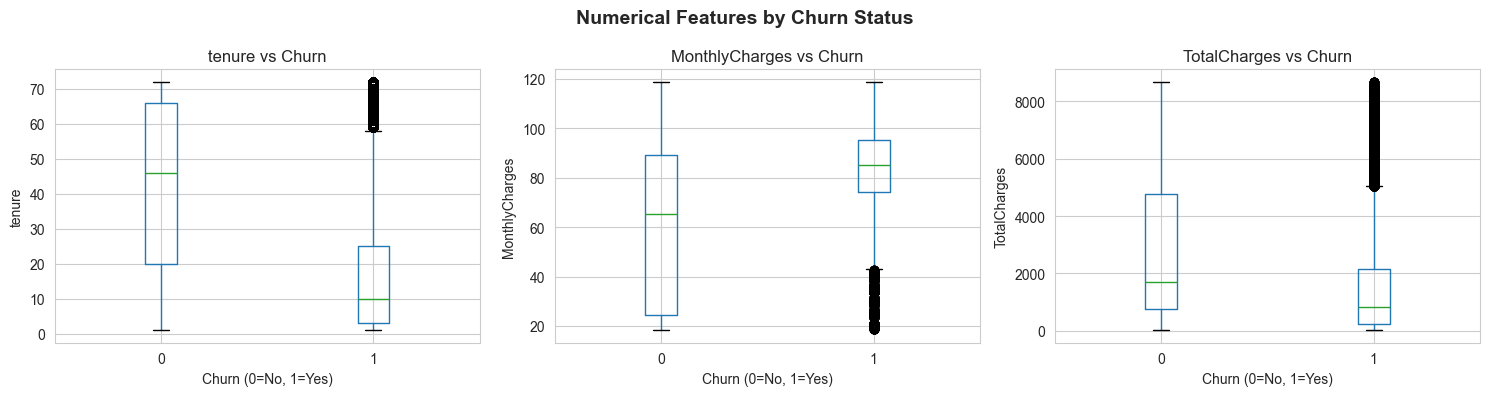


Average values by Churn status:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
0      42.231313       61.293633   2771.500515
1      17.125343       81.597525   1540.976020

--- 3.3: Categorical Features Analysis ---


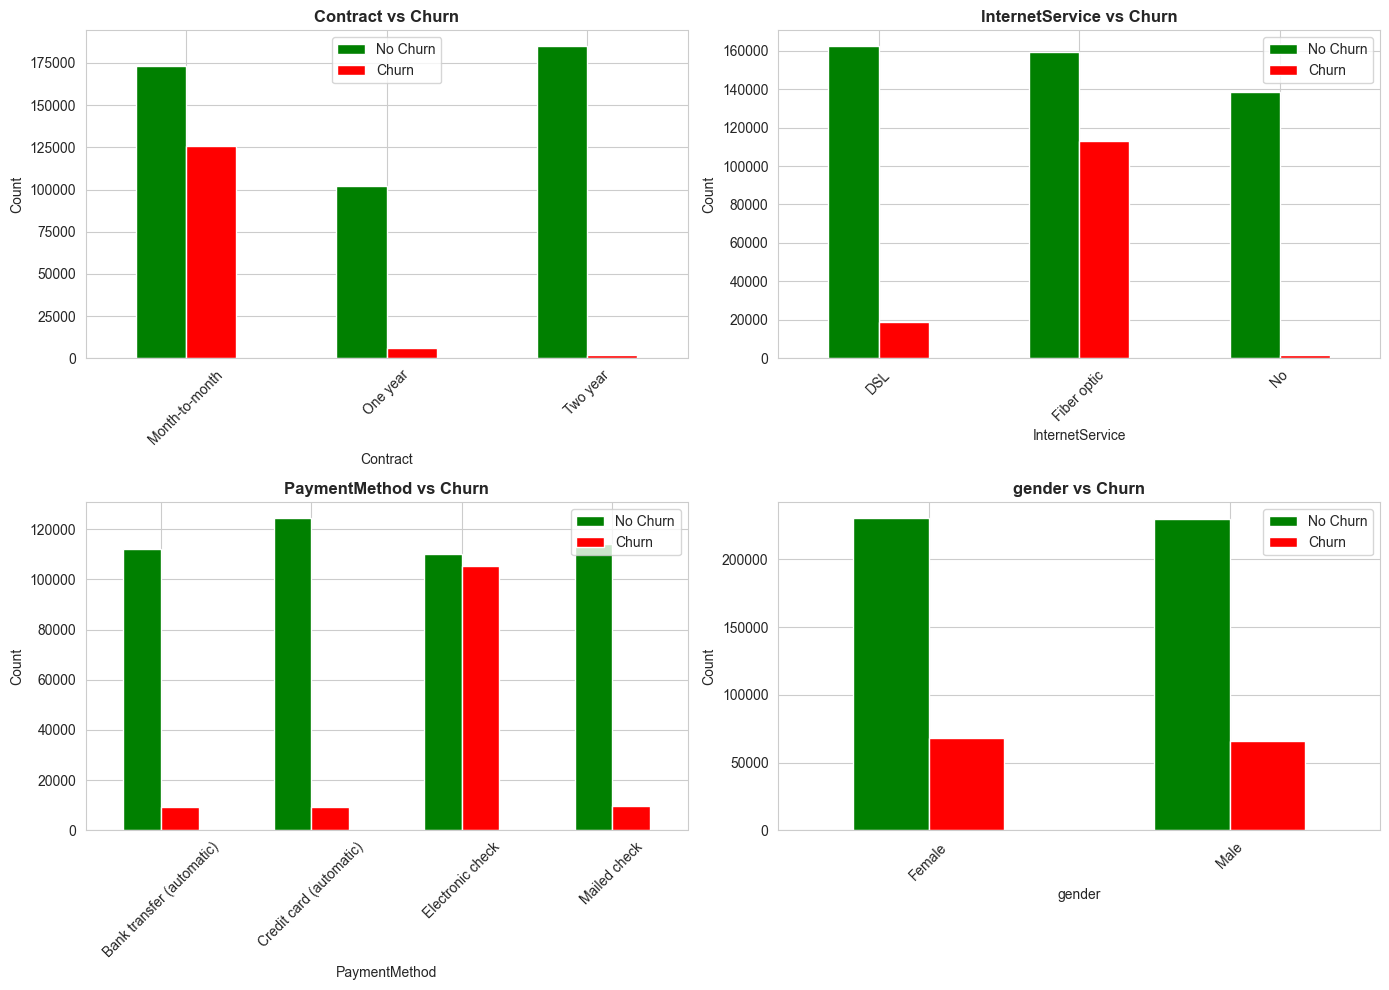


--- 3.4: Churn Rate by Category ---

Contract:
  Month-to-month                : 42.05%
  One year                      :  5.76%
  Two year                      :  1.00%

InternetService:
  Fiber optic                   : 41.54%
  DSL                           : 10.31%
  No                            :  1.43%

PaymentMethod:
  Electronic check              : 48.91%
  Mailed check                  :  7.97%
  Bank transfer (automatic)     :  7.71%
  Credit card (automatic)       :  6.93%

gender:
  Female                        : 22.80%
  Male                          : 22.23%

--- 3.5: Correlation Analysis ---


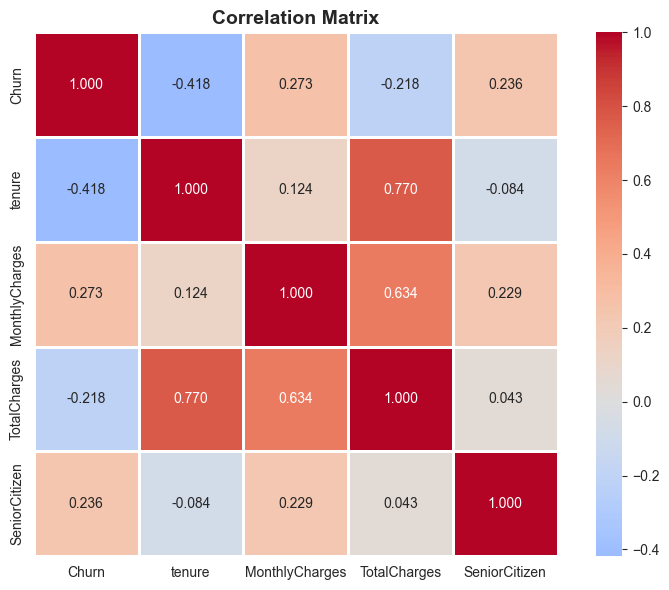


Correlation with Churn:
Churn             1.000000
MonthlyCharges    0.272997
SeniorCitizen     0.236362
TotalCharges     -0.218365
tenure           -0.418453
Name: Churn, dtype: float64

✅ EDA complete!


In [ ]:

# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# import matplotlib.pyplot as plt
# import seaborn as sns

# Set style for prettier charts
# sns.set_style("whitegrid")
# plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 60)
print("SECTION 3: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ------------------------------------------------
# 3.1: Target Distribution
# ------------------------------------------------
print("\n--- 3.1: Target Variable Distribution ---")
churn_counts = train['Churn'].value_counts()
# plt.figure(figsize=(8, 5))
# plt.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['green', 'red'])
# plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
# plt.ylabel('Number of Customers')
# plt.xlabel('Churn Status')
# for i, v in enumerate(churn_counts.values):
#     plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')
# plt.tight_layout()
# plt.show()

# ------------------------------------------------
# 3.2: Numerical Features Analysis
# ------------------------------------------------
print("\n--- 3.2: Numerical Features Analysis ---")

# Select numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for idx, col in enumerate(numerical_cols):
#     train.boxplot(column=col, by='Churn', ax=axes[idx])
#     axes[idx].set_title(f'{col} vs Churn')
#     axes[idx].set_xlabel('Churn (0=No, 1=Yes)')
#     axes[idx].set_ylabel(col)
# plt.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# Statistics by churn
print("\nAverage values by Churn status:")
print(train.groupby('Churn')[numerical_cols].mean())

# ------------------------------------------------
# 3.3: Categorical Features Analysis
# ------------------------------------------------
print("\n--- 3.3: Categorical Features Analysis ---")

# Important categorical columns
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# axes = axes.ravel()
# for idx, col in enumerate(categorical_cols):
#     churn_data = train.groupby([col, 'Churn']).size().unstack()
#     churn_data.plot(kind='bar', ax=axes[idx], color=['green', 'red'])
#     axes[idx].set_title(f'{col} vs Churn', fontweight='bold')
#     axes[idx].set_xlabel(col)
#     axes[idx].set_ylabel('Count')
#     axes[idx].legend(['No Churn', 'Churn'])
#     axes[idx].tick_params(axis='x', rotation=45)
# plt.tight_layout()
# plt.show()

# ------------------------------------------------
# 3.4: Churn Rate by Categories
# ------------------------------------------------
print("\n--- 3.4: Churn Rate by Category ---")

for col in categorical_cols:
    churn_rate = train.groupby(col)['Churn'].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    for category, rate in churn_rate.items():
        print(f"  {category:30s}: {rate*100:5.2f}%")

# ------------------------------------------------
# 3.5: Correlation Matrix (Numerical Features)
# ------------------------------------------------
print("\n--- 3.5: Correlation Analysis ---")

corr_cols = ['Churn', 'tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
correlation = train[corr_cols].corr()

# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
#             fmt='.3f', square=True, linewidths=1)
# plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

print("\nCorrelation with Churn:")
print(correlation['Churn'].sort_values(ascending=False))

print("\n✅ EDA complete!")
